# NLP Task 
## Rating Prediciton using Hotel Review Dataset
**Module:** Artificial Intelligence and Machine Learning  
**Institution:** Herald College Kathmandu  
**Submitted Date:** May 10, 2026

---

### Student Details

| Name | ID Number | Group |
| :--- | :--- | :--- |
| **Narayan Lohani** | 2408869 | L6CG15 |

---

<div style="display: flex; justify-content: space-between; align-items: center; border: none;">
  <img src="https://heraldcollege.edu.np/images/footer/footer-logo-dark.svg" width="180" alt="Herald College Logo">
  <img src="https://bizzeducation.com/storage/university-partners/May2024/r3iG0n8CHfh1nCAIz5BO.png" width="180" alt="University of Wolverhampton Logo">
</div>

In [ ]:
from google.colab import drive

drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 📦 0. Install & Import Dependencies

In [ ]:
import os

!pip install wordcloud contractions gradio
!pip install gensim nltk
!pip install jax==0.4.13
!pip install --upgrade jax jaxlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.6 MB/s eta 0:00:00
  Using cached jax-0.4.13-py3-none-any.whl
  Attempting uninstall: jax
    Found existing installation: jax 0.10.0
    Uninstalling jax-0.10.0:
      Successfully uninstalled jax-0.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
optax 0.2.8 requires jax>=0.5.3, but you have jax 0.4.13 which is incompatible.
orbax-checkpoint 0.11.36 requires jax>=0.6.0, but you have jax 0.4.13 which is incompatible.
flax 0.11.2 requires jax>=0.6.0, but you have jax 0.4.13 which is incompatible.
  Using cached jax-0.10.0-py3-none-any.whl.metadata (13 kB)
Using cached jax-0.10.0-py3-none-any.whl (3.1 MB)
  Attempting uninstall: jax
    Found existing installation: jax 0.4.13
    Uninstalling jax-0.4.13:
      Successf

In [ ]:
# ── Standard Library & Utilities ─────────────────────────────────────────────
import re
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

warnings.filterwarnings("ignore")

# ── NLP & Text Processing ────────────────────────────────────────────────────
import nltk
import contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import gensim.downloader as gensim_dl

# NLTK Downloads
for pkg in ["stopwords", "wordnet", "omw-1.4", "punkt"]:
    nltk.download(pkg, quiet=True)

# ── Machine Learning (Scikit-Learn) ──────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

# ── Deep Learning (TensorFlow / Keras) ───────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    Dense,
    Dropout,
    SpatialDropout1D,
    BatchNormalization,
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# ── Reproducibility & Initialization ─────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow  : {tf.__version__}")
print(f"NumPy       : {np.__version__}")
print("All libraries loaded successfully! ✓")


TensorFlow  : 2.20.0
NumPy       : 2.0.2
All libraries loaded successfully! ✓


---
## 4.5.1 : Text Preprocessing

### 4.5.1.1 Load Data

In [ ]:
# df = pd.read_csv("Dataset/Hotel_Reviews.csv")
df = pd.read_csv("/content/drive/MyDrive/ai/ai - assessment: Group A/Hotel_Reviews.csv")

print(f"Dataset shape : {df.shape}")
print(f'Rating distribution:\n{df["Rating"].value_counts().sort_index()}')
df.head()


Dataset shape : (20491, 2)
Rating distribution:
Rating
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


### 4.5.1.2 Text Cleaning Function

In [ ]:
STOP_WORDS = set(stopwords.words("english"))

# ── FIX 1: Remove negation words from stopword list ──────────────────────────
# Words like "not", "no", "nor", "never", "but" carry critical sentiment signal.
# Removing them from stopwords preserves negation context for the model.
NEGATION_WORDS = {
    "not",
    "no",
    "nor",
    "never",
    "but",
    "without",
    "nobody",
    "nothing",
    "nowhere",
    "neither",
    "hardly",
    "barely",
    "scarcely",
    "don",
    "didn",
    "doesn",
    "isn",
    "wasn",
    "aren",
    "weren",
    "haven",
    "hasn",
    "hadn",
    "won",
    "wouldn",
    "couldn",
    "shouldn",
    "mustn",
}
STOP_WORDS -= NEGATION_WORDS

lemmatizer = WordNetLemmatizer()


def clean_text(text: str) -> str:
    """Full NLP preprocessing pipeline for a single review string."""

    # 1. Expand contractions  (e.g., "don't" → "do not")
    text = contractions.fix(text)

    # 2. Lowercase
    text = text.lower()

    # 3. Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", "", text)

    # 4. Remove @mentions and #hashtags
    text = re.sub(r"@\w+|#\w+", "", text)

    # 5. Remove numbers
    text = re.sub(r"\d+", "", text)

    # 6. Remove special characters (keep only alphabetic + spaces)
    text = re.sub(r"[^a-z\s]", "", text)

    # 7. Tokenise, remove stopwords, lemmatise
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(tok)
        for tok in tokens
        if tok not in STOP_WORDS and len(tok) > 1
    ]

    return " ".join(tokens)


# Apply to the entire corpus
df["clean_review"] = df["Review"].apply(clean_text)

# Sanity check
print("Original :", df["Review"].iloc[0])
print("Cleaned  :", df["clean_review"].iloc[0])


Original : nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick easy, little disappointed non-existent view room room clean nice size, bed comfortable woke stiff neck high pillows, not soundproof like heard music room night morning loud bangs doors opening closing hear people talking hallway, maybe just noisy neighbors, aveda bath products nice, did not goldfish stay nice touch taken advantage staying longer, location great walking distance shopping, overall nice experience having pay 40 parking night,  
Cleaned  : nice hotel expensive parking got good deal stay hotel anniversary arrived late evening took advice previous review valet parking check quick easy little disappointed nonexistent view room room clean nice size bed comfortable woke stiff neck high pillow not soundproof like heard music room night morning loud bang door opening closing hear people talking hallway maybe noisy neighbor 

### 4.5.1.3 Word Cloud & Frequency Plot

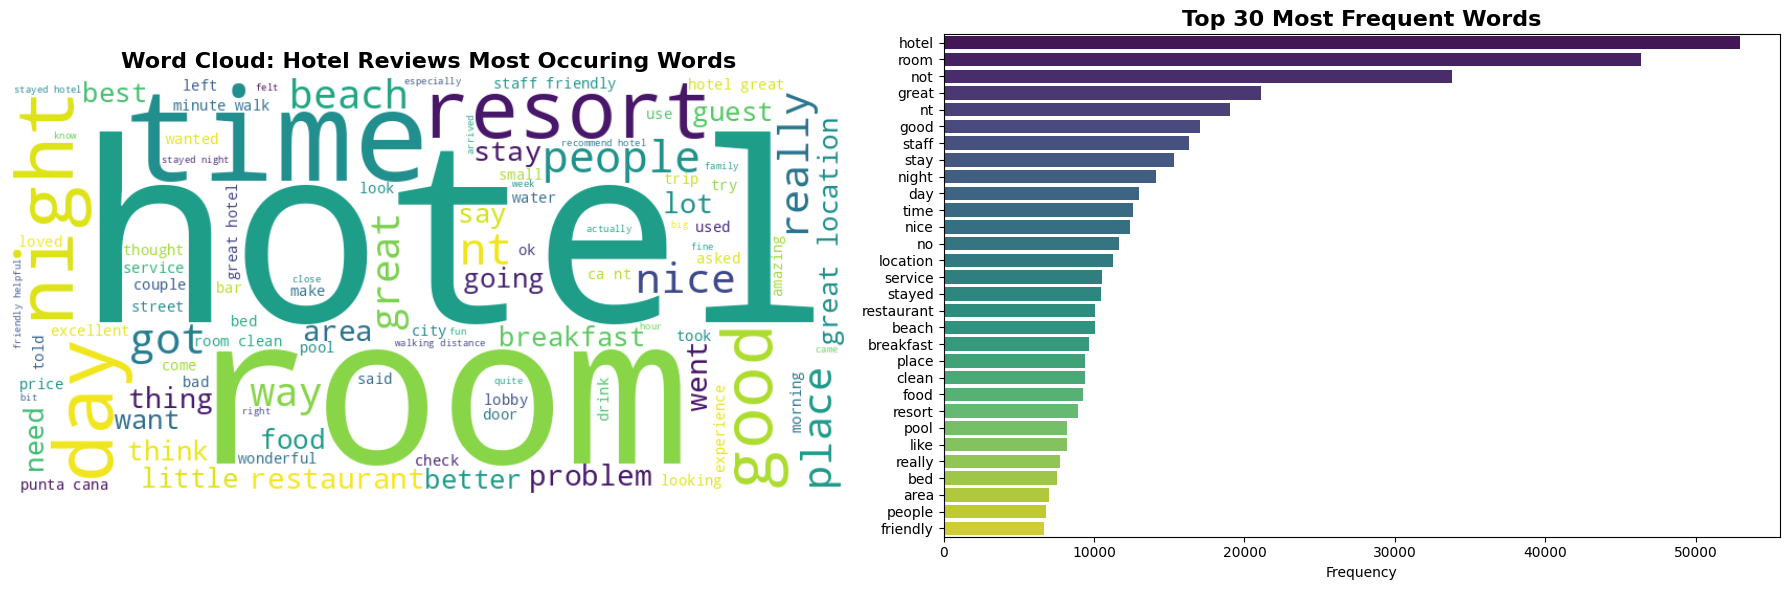

Unique vocabulary size: 70,943


In [ ]:
all_words = " ".join(df["clean_review"])
word_freq = Counter(all_words.split())

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Word Cloud ────────────────────────────────────────────────────────────────
wc = WordCloud(
    width=800, height=400, background_color="white", colormap="viridis", max_words=100
).generate(all_words)

axes[0].imshow(wc, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title(
    "Word Cloud: Hotel Reviews Most Occuring Words", fontsize=16, fontweight="bold"
)

# ── Top-30 Frequency Bar Chart ────────────────────────────────────────────────
top_words = pd.DataFrame(word_freq.most_common(30), columns=["Word", "Count"])
sns.barplot(data=top_words, x="Count", y="Word", palette="viridis", ax=axes[1])
axes[1].set_title("Top 30 Most Frequent Words", fontsize=16, fontweight="bold")
axes[1].set_xlabel("Frequency")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()
print(f"Unique vocabulary size: {len(word_freq):,}")


### 4.5.1.4 Train / Test Split

In [ ]:
df["label"] = df["Rating"] - 1  # 0-indexed: {0,1,2,3,4}
NUM_CLASSES = df["label"].nunique()  # 5

X = df["clean_review"].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Training samples   : {len(X_train)}")
print(f"Test samples       : {len(X_test)}")
print(f"Number of classes  : {NUM_CLASSES}")


Training samples   : 16392
Test samples       : 4099
Number of classes  : 5


### 4.5.1.5 Keras Tokenizer & Percentile-Based Padding

Sequence length stats (train):
  min=8, max=1886, mean=99.6, 90th-pct=191


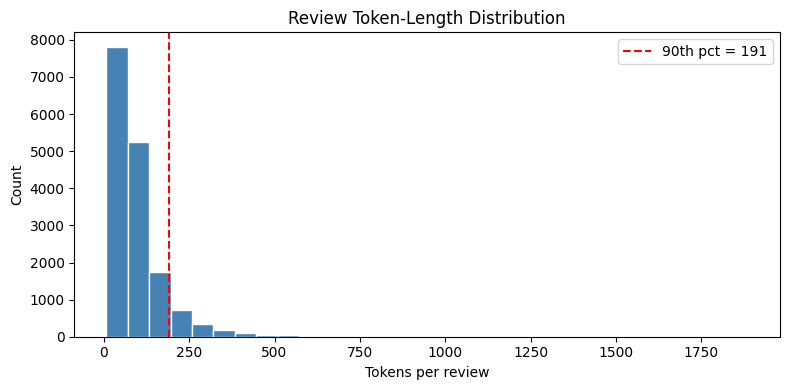


X_train_pad shape : (16392, 191)
X_test_pad  shape : (4099, 191)

Class weights: {0: np.float64(2.883377308707124), 1: np.float64(2.2861924686192467), 2: np.float64(1.876588437321122), 3: np.float64(0.6786172635065204), 4: np.float64(0.45263012563854754)}


In [ ]:
VOCAB_SIZE = 10_000  # FIX 2: larger vocabulary captures more domain terms
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)  # fit ONLY on training data

train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

# ── FIX 3: Use 90th percentile to retain more review context ─────────────────
# The original 80th pct truncated 20% of reviews, discarding late-review
# sentiment signals. 90th pct is a better trade-off of memory vs. coverage.
train_lengths = [len(s) for s in train_sequences]
PERCENTILE = 90
MAX_LEN = int(np.percentile(train_lengths, PERCENTILE))
print(f"Sequence length stats (train):")
print(
    f"  min={min(train_lengths)}, max={max(train_lengths)}, "
    f"mean={np.mean(train_lengths):.1f}, {PERCENTILE}th-pct={MAX_LEN}"
)

# Visualise length distribution
plt.figure(figsize=(8, 4))
plt.hist(train_lengths, bins=30, color="steelblue", edgecolor="white")
plt.axvline(
    MAX_LEN, color="red", linestyle="--", label=f"{PERCENTILE}th pct = {MAX_LEN}"
)
plt.title("Review Token-Length Distribution")
plt.xlabel("Tokens per review")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# ── Pad / truncate sequences ──────────────────────────────────────────────────
X_train_pad = pad_sequences(
    train_sequences, maxlen=MAX_LEN, padding="post", truncating="post"
)
X_test_pad = pad_sequences(
    test_sequences, maxlen=MAX_LEN, padding="post", truncating="post"
)

print(f"\nX_train_pad shape : {X_train_pad.shape}")
print(f"X_test_pad  shape : {X_test_pad.shape}")

# ── FIX 4: Compute class weights to handle rating-imbalance ──────────────────
from sklearn.utils.class_weight import compute_class_weight

class_weights_arr = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
CLASS_WEIGHTS = dict(enumerate(class_weights_arr))
print(f"\nClass weights: {CLASS_WEIGHTS}")

# ── One-hot labels for categorical_crossentropy ───────────────────────────────
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_cat = to_categorical(y_test, num_classes=NUM_CLASSES)


---
## 4.5.2 : Model Building

### 4.5.2.1 Shared Hyperparameters

In [ ]:
# ── FIX 5: Increased capacity ─────────────────────────────────────────────────
EMBED_DIM = 128  # was 50  – richer token representations
RNN_UNITS = 128  # was 64  – more recurrent memory
LSTM_UNITS = 128  # was 64
DROPOUT_R = 0.4  # slightly higher to match larger model
BATCH_SIZE = 64  # larger batches → more stable gradient estimates
EPOCHS = 30  # EarlyStopping will interrupt earlier


# ── Callbacks (shared) ───────────────────────────────────────────────────────
def make_callbacks(model_name: str):
    """Return EarlyStopping + ModelCheckpoint + ReduceLROnPlateau callbacks."""
    es = EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
    )
    ckpt = ModelCheckpoint(
        filepath=f"models/best_{model_name}.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=0,
    )
    # FIX 6: Actually wire in ReduceLROnPlateau (was imported but never used)
    rlrop = ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1
    )
    return [es, ckpt, rlrop]


### 4.5.2.2 Model 1 : Simple RNN

In [ ]:
from tensorflow.keras.layers import Bidirectional


def build_simple_rnn():
    """
    FIX 7: Bidirectional SimpleRNN.
    Wrapping in Bidirectional doubles the effective units and lets the model
    read the review from both ends, helping capture late-appearing negations.
    An extra Dense(64) hidden layer adds non-linear capacity before the
    classification head.
    """
    model = Sequential(
        [
            Embedding(
                input_dim=VOCAB_SIZE,
                output_dim=EMBED_DIM,
                input_length=MAX_LEN,
                name="embedding",
            ),
            SpatialDropout1D(DROPOUT_R),
            Bidirectional(SimpleRNN(units=RNN_UNITS), name="bi_simple_rnn"),
            BatchNormalization(),
            Dropout(DROPOUT_R),
            Dense(64, activation="relu", name="hidden"),
            Dropout(DROPOUT_R),
            Dense(NUM_CLASSES, activation="softmax", name="output"),
        ],
        name="Model1_Bi_SimpleRNN",
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


model1 = build_simple_rnn()
model1.summary()


Model: "Model1_Bi_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_4             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_simple_rnn (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 4.5.2.3 Model 2 : LSTM

In [ ]:
def build_lstm():
    """
    FIX 8: Stacked Bidirectional LSTM.
    - Two Bi-LSTM layers: the first returns sequences so the second can
      process the full temporal output, not just the final hidden state.
    - BatchNormalization after the recurrent block stabilises training.
    - Extra Dense(64) hidden layer before the softmax head.
    """
    model = Sequential(
        [
            Embedding(
                input_dim=VOCAB_SIZE,
                output_dim=EMBED_DIM,
                input_length=MAX_LEN,
                name="embedding",
            ),
            SpatialDropout1D(DROPOUT_R),
            Bidirectional(
                LSTM(units=LSTM_UNITS, return_sequences=True), name="bi_lstm_1"
            ),
            Bidirectional(LSTM(units=LSTM_UNITS // 2), name="bi_lstm_2"),
            BatchNormalization(),
            Dropout(DROPOUT_R),
            Dense(64, activation="relu", name="hidden"),
            Dropout(DROPOUT_R),
            Dense(NUM_CLASSES, activation="softmax", name="output"),
        ],
        name="Model2_Stacked_BiLSTM",
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


model2 = build_lstm()
model2.summary()


Model: "Model2_Stacked_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_5             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_lstm_1 (Bidirectional)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_lstm_2 (Bidirectional)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 4.5.2.4 Model 3 : LSTM + Pre-trained GloVe Embeddings

In [ ]:
# FIX 9: Use GloVe Wikipedia 100d instead of Twitter 50d.
# Wikipedia vectors are trained on formal text, much closer to hotel review
# language than Twitter. 100 dimensions carry substantially more semantic
# information than 50d at a modest memory cost.
print("Downloading GloVe Wikipedia 100d vectors (≈ 400 MB, one-time) …")
glove_model = gensim_dl.load("glove-twitter-100")
print("GloVe loaded.")
print(f"Vocabulary in GloVe: {len(glove_model):,}")
GLOVE_DIM = 100  # must match the loaded model


GloVe loaded.
Vocabulary in GloVe: 1,193,514


In [ ]:
word_index = tokenizer.word_index
hits, misses = 0, 0

embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in glove_model:
        embedding_matrix[idx] = glove_model[word]
        hits += 1
    else:
        embedding_matrix[idx] = np.random.normal(scale=0.1, size=GLOVE_DIM)
        misses += 1

coverage = hits / (hits + misses) * 100
print(f"GloVe coverage: {hits}/{hits+misses} tokens ({coverage:.1f} %)")
print(f"Embedding matrix shape: {embedding_matrix.shape}")


GloVe coverage: 9283/9999 tokens (92.8 %)
Embedding matrix shape: (10000, 100)


In [ ]:
def build_lstm_glove():
    """
    FIX 10: GloVe embedding fine-tuning strategy.
    - Start frozen (trainable=False) for the first phase so the LSTM learns
      to use the GloVe vectors without corrupting them immediately.
    - After warm-up training (below), set trainable=True and re-compile with
      a very low learning rate so the embeddings adapt gently.
    - Stacked Bi-LSTM + hidden Dense for full parity with Model 2.
    """
    model = Sequential(
        [
            Embedding(
                input_dim=VOCAB_SIZE,
                output_dim=GLOVE_DIM,
                input_length=MAX_LEN,
                weights=[embedding_matrix],
                trainable=False,  # frozen during warm-up phase
                name="glove_embedding",
            ),
            SpatialDropout1D(DROPOUT_R),
            Bidirectional(
                LSTM(units=LSTM_UNITS, return_sequences=True), name="bi_lstm_1"
            ),
            Bidirectional(LSTM(units=LSTM_UNITS // 2), name="bi_lstm_2"),
            BatchNormalization(),
            Dropout(DROPOUT_R),
            Dense(64, activation="relu", name="hidden"),
            Dropout(DROPOUT_R),
            Dense(NUM_CLASSES, activation="softmax", name="output"),
        ],
        name="Model3_BiLSTM_GloVe",
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


model3 = build_lstm_glove()
model3.summary()


Model: "Model3_BiLSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_6             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_lstm_1 (Bidirectional)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_lstm_2 (Bidirectional)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

---
## 4.5.3 : Training

### 4.5.3.1 Train Model 1 : Simple RNN

In [ ]:
history1 = model1.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_test_pad, y_test_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=CLASS_WEIGHTS,  # FIX 4 applied
    callbacks=make_callbacks("model1_rnn"),
    verbose=1,
)


Epoch 1/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - accuracy: 0.2315 - loss: 1.9310 - val_accuracy: 0.2884 - val_loss: 1.4935 - learning_rate: 0.0010
Epoch 2/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.3561 - loss: 1.4779 - val_accuracy: 0.4594 - val_loss: 1.7163 - learning_rate: 0.0010
Epoch 3/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4159 - loss: 1.3586
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
257/257 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.4332 - loss: 1.3191 - val_accuracy: 0.3120 - val_loss: 2.0707 - learning_rate: 0.0010
Epoch 4/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.4961 - loss: 1.1976 - val_accuracy: 0.1649 - val_loss: 3.6266 - learning_rate: 5.0000e-04
Epoch 5/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5099 - loss: 1.1630
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
257/257 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.5126 - loss:

### 4.5.3.2 Train Model 2 : LSTM

In [ ]:
history2 = model2.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_test_pad, y_test_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=CLASS_WEIGHTS,  # FIX 4 applied
    callbacks=make_callbacks("model2_lstm"),
    verbose=1,
)


Epoch 1/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.4451 - loss: 1.2911 - val_accuracy: 0.5465 - val_loss: 1.3426 - learning_rate: 0.0010
Epoch 2/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - accuracy: 0.5873 - loss: 0.9857 - val_accuracy: 0.5111 - val_loss: 1.0903 - learning_rate: 0.0010
Epoch 3/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - accuracy: 0.6321 - loss: 0.8550 - val_accuracy: 0.5926 - val_loss: 1.0399 - learning_rate: 0.0010
Epoch 4/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.6646 - loss: 0.7462 - val_accuracy: 0.5977 - val_loss: 1.1246 - learning_rate: 0.0010
Epoch 5/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6853 - loss: 0.7011
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
257/257 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.6893 - loss: 0.6684 - val_accuracy: 0.5248 - val_loss: 1.9237 - learning_rate: 0.0010
Epoch 6/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.7339 - los

### 4.5.3.3 Train Model 3 : LSTM + GloVe

In [ ]:
# ── Phase 1: Frozen embedding warm-up (5 epochs) ─────────────────────────────
print("=" * 60)
print("Phase 1 : Warm-up with frozen GloVe embeddings …")
print("=" * 60)
history3_warmup = model3.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_test_pad, y_test_cat),
    epochs=5,
    batch_size=BATCH_SIZE,
    class_weight=CLASS_WEIGHTS,
    verbose=1,
)

# ── Phase 2: Unfreeze embedding, fine-tune with tiny LR ──────────────────────
# FIX 10 (cont.): Unfreeze the GloVe layer so it adapts to hotel-review
# vocabulary while the LSTM is already partially trained. Use a 10× smaller
# learning rate to avoid destroying the pre-trained vectors.
print("\n" + "=" * 60)
print("Phase 2 : Fine-tuning GloVe embeddings …")
print("=" * 60)
model3.layers[0].trainable = True  # glove_embedding layer
model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history3 = model3.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_test_pad, y_test_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=CLASS_WEIGHTS,
    callbacks=make_callbacks("model3_glove"),
    verbose=1,
)


Phase 1 : Warm-up with frozen GloVe embeddings …
Epoch 1/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.3633 - loss: 1.6174 - val_accuracy: 0.3962 - val_loss: 1.3319
Epoch 2/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.4547 - loss: 1.2808 - val_accuracy: 0.5192 - val_loss: 1.0912
Epoch 3/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.5015 - loss: 1.1864 - val_accuracy: 0.5821 - val_loss: 0.9240
Epoch 4/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.5335 - loss: 1.1254 - val_accuracy: 0.5919 - val_loss: 0.8981
Epoch 5/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.5478 - loss: 1.0794 - val_accuracy: 0.5940 - val_loss: 0.8993

Phase 2 : Fine-tuning GloVe embeddings …
Epoch 1/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 18s 53ms/step - accuracy: 0.5691 - loss: 1.0358 - val_accuracy: 0.5938 - val_loss: 0.9028 - learning_rate: 1.0000e-04
Epoch 2/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.5733 - loss: 1.0206 - val_accuracy: 0.

### 4.5.3.4 Training Curves : Loss & Accuracy (All Three Models)

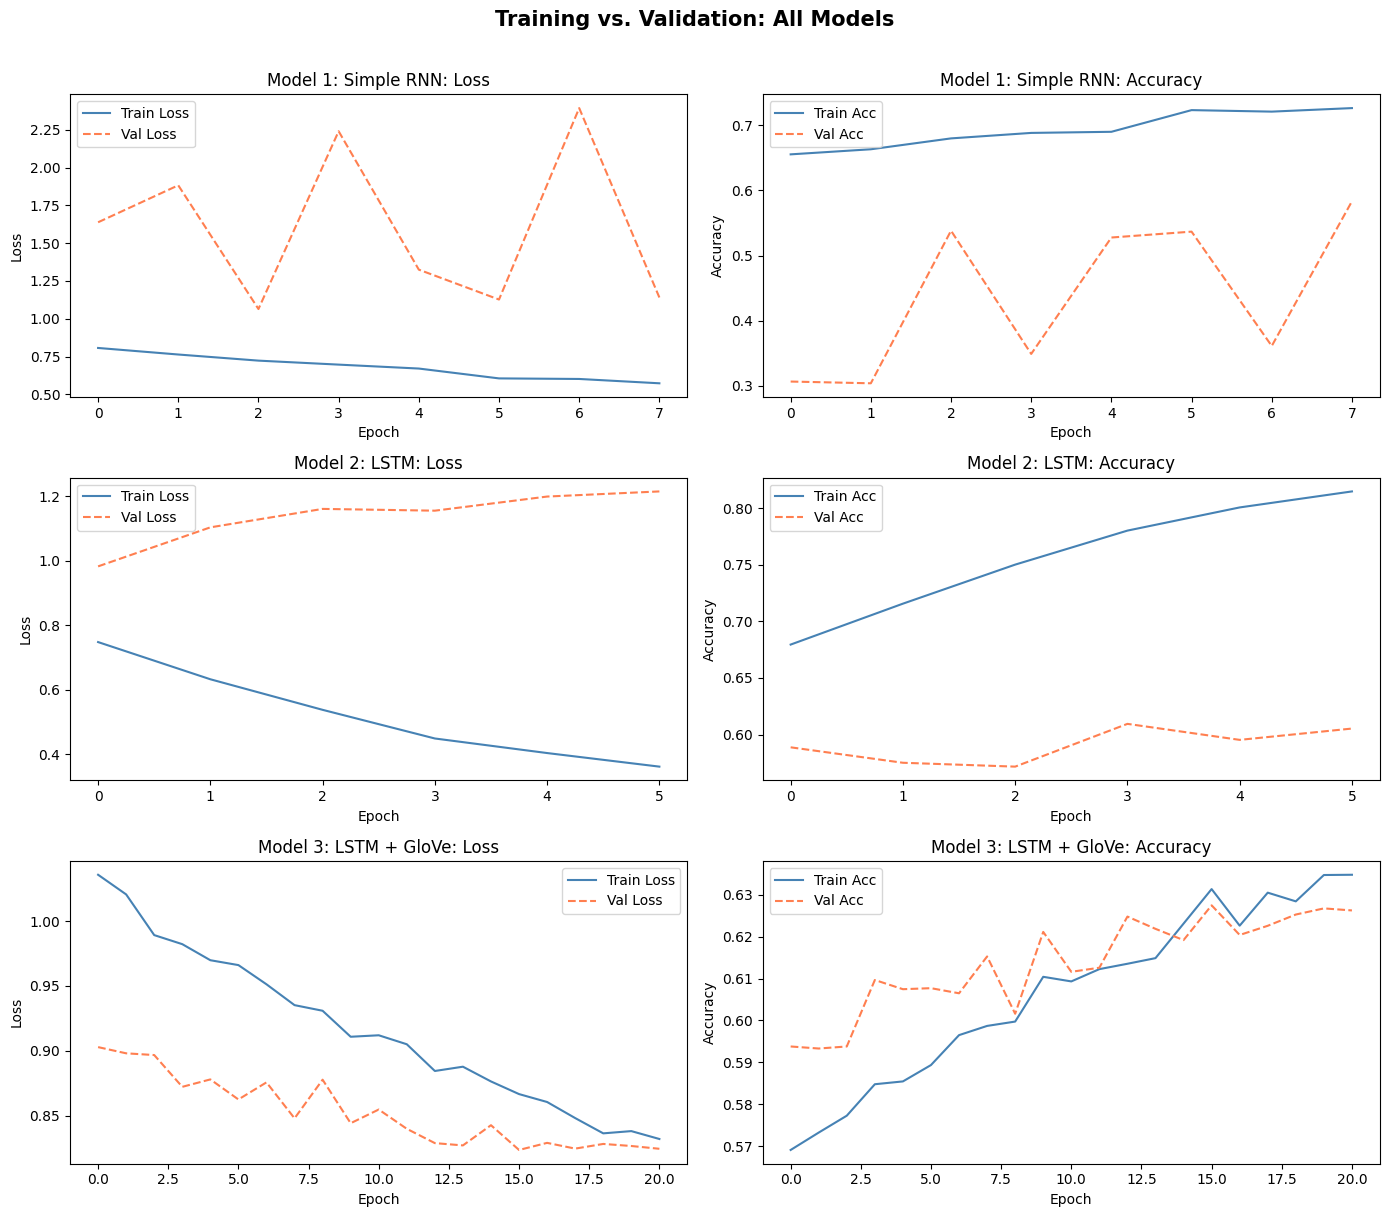

In [ ]:
def plot_history(histories, names):
    """Plot loss and accuracy curves for multiple Keras histories."""
    fig, axes = plt.subplots(len(histories), 2, figsize=(14, 4 * len(histories)))

    for i, (hist, name) in enumerate(zip(histories, names)):
        h = hist.history

        # Loss
        axes[i, 0].plot(h["loss"], label="Train Loss", color="steelblue")
        axes[i, 0].plot(h["val_loss"], label="Val Loss", color="coral", linestyle="--")
        axes[i, 0].set_title(f"{name}: Loss")
        axes[i, 0].set_xlabel("Epoch")
        axes[i, 0].set_ylabel("Loss")
        axes[i, 0].legend()

        # Accuracy
        axes[i, 1].plot(h["accuracy"], label="Train Acc", color="steelblue")
        axes[i, 1].plot(
            h["val_accuracy"], label="Val Acc", color="coral", linestyle="--"
        )
        axes[i, 1].set_title(f"{name}: Accuracy")
        axes[i, 1].set_xlabel("Epoch")
        axes[i, 1].set_ylabel("Accuracy")
        axes[i, 1].legend()

    plt.suptitle(
        "Training vs. Validation: All Models", fontsize=15, fontweight="bold", y=1.01
    )
    plt.tight_layout()
    plt.show()


plot_history(
    [history1, history2, history3],
    ["Model 1: Simple RNN", "Model 2: LSTM", "Model 3: LSTM + GloVe"],
)


---
## 4.5.4 : Evaluation

### 4.5.4.1 Confusion Matrix & Classification Report


════════════════════════════════════════════════════════════
 Model 1 : Simple RNN
════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

    Rating 1       0.68      0.50      0.57       284
    Rating 2       0.37      0.40      0.39       359
    Rating 3       0.29      0.56      0.38       437
    Rating 4       0.47      0.46      0.47      1208
    Rating 5       0.77      0.61      0.68      1811

    accuracy                           0.54      4099
   macro avg       0.51      0.51      0.50      4099
weighted avg       0.59      0.54      0.55      4099



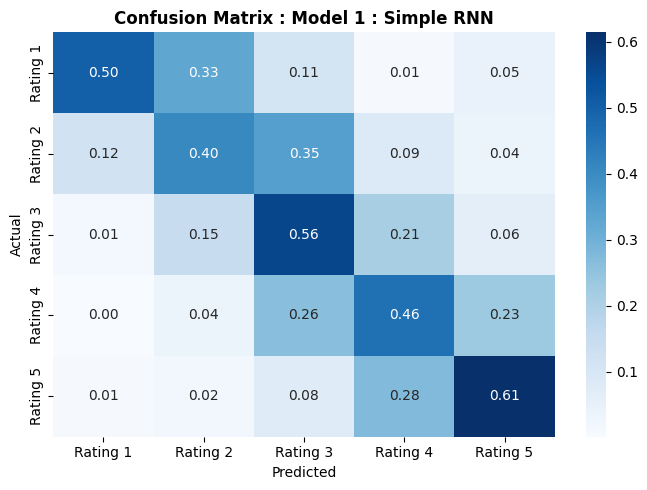


════════════════════════════════════════════════════════════
 Model 2 : LSTM
════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

    Rating 1       0.48      0.76      0.59       284
    Rating 2       0.39      0.52      0.44       359
    Rating 3       0.32      0.31      0.32       437
    Rating 4       0.54      0.44      0.48      1208
    Rating 5       0.76      0.74      0.75      1811

    accuracy                           0.59      4099
   macro avg       0.50      0.55      0.52      4099
weighted avg       0.60      0.59      0.59      4099



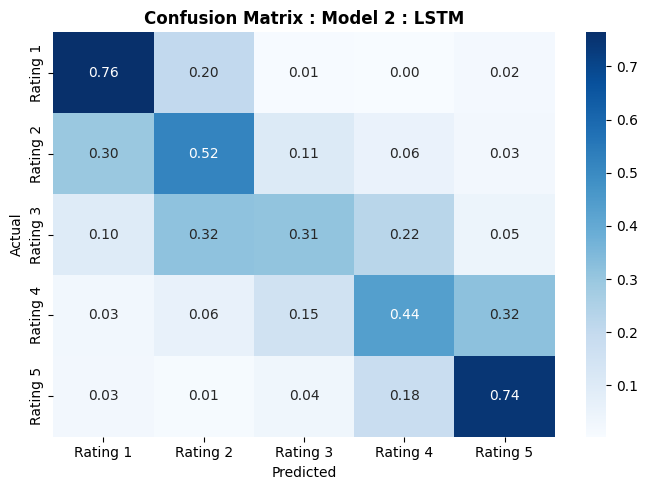


════════════════════════════════════════════════════════════
 Model 3 : LSTM + GloVe
════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

    Rating 1       0.72      0.69      0.70       284
    Rating 2       0.48      0.51      0.49       359
    Rating 3       0.36      0.53      0.43       437
    Rating 4       0.56      0.49      0.52      1208
    Rating 5       0.78      0.76      0.77      1811

    accuracy                           0.63      4099
   macro avg       0.58      0.60      0.58      4099
weighted avg       0.64      0.63      0.63      4099



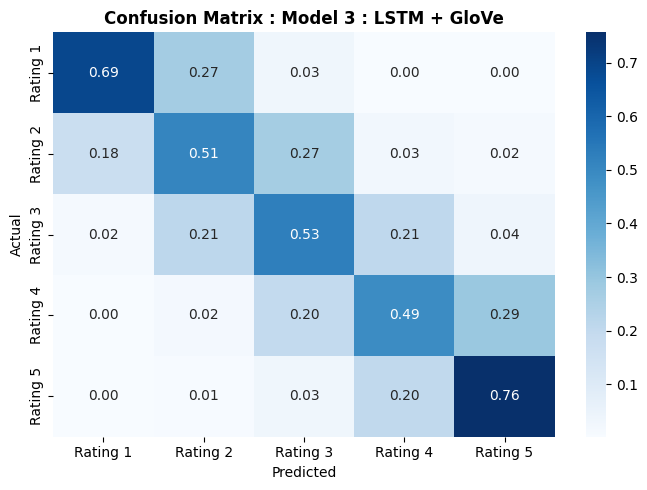

In [ ]:
CLASS_NAMES = [f"Rating {r}" for r in range(1, 6)]  # 1-5


def evaluate_model(model, model_name, X, y_true_int):
    """Predict, print classification report, and plot confusion matrix."""
    y_pred_proba = model.predict(X, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    print(f'\n{"═" * 60}')
    print(f" {model_name}")
    print(f'{"═" * 60}')
    print(
        classification_report(
            y_true_int, y_pred, target_names=CLASS_NAMES, zero_division=0
        )
    )

    # Normalised confusion matrix
    cm = confusion_matrix(y_true_int, y_pred, normalize="true")
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix : {model_name}", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return y_pred


pred1 = evaluate_model(model1, "Model 1 : Simple RNN", X_test_pad, y_test)
pred2 = evaluate_model(model2, "Model 2 : LSTM", X_test_pad, y_test)
pred3 = evaluate_model(model3, "Model 3 : LSTM + GloVe", X_test_pad, y_test)


### 4.5.4.2 Summary Comparison Table

       Model  Test Accuracy  Test Accuracy (%)
  Simple RNN        0.53818              53.82
        LSTM        0.58868              58.87
LSTM + GloVe        0.62747              62.75


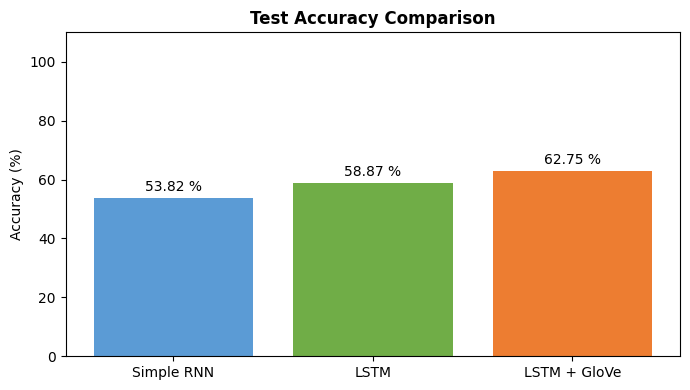

In [ ]:
from sklearn.metrics import accuracy_score

results = pd.DataFrame(
    {
        "Model": ["Simple RNN", "LSTM", "LSTM + GloVe"],
        "Test Accuracy": [
            accuracy_score(y_test, pred1),
            accuracy_score(y_test, pred2),
            accuracy_score(y_test, pred3),
        ],
    }
)
results["Test Accuracy (%)"] = (results["Test Accuracy"] * 100).round(2)

print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    results["Model"],
    results["Test Accuracy (%)"],
    color=["#5b9bd5", "#70ad47", "#ed7d31"],
)
ax.bar_label(bars, fmt="%.2f %%", padding=3)
ax.set_ylim(0, 110)
ax.set_title("Test Accuracy Comparison", fontweight="bold")
ax.set_ylabel("Accuracy (%)")
plt.tight_layout()
plt.show()


### 4.5.4.3 Error Analysis : Misclassified Reviews

In [ ]:
def error_analysis(model, model_name, X_pad, X_raw, y_true_int, n=2):
    """
    Find the n most confidently misclassified reviews, display them, and
    provide a brief diagnostic explanation.

    Parameters
    ----------
    model       : trained Keras model
    model_name  : display name
    X_pad       : padded test sequences (numpy array)
    X_raw       : original (uncleaned) test reviews
    y_true_int  : 0-indexed integer labels
    n           : number of examples to display
    """
    y_pred_proba = model.predict(X_pad, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    confidence = np.max(y_pred_proba, axis=1)

    # Mask of misclassified rows
    wrong_mask = y_pred != y_true_int
    wrong_indices = np.where(wrong_mask)[0]

    if len(wrong_indices) == 0:
        print(f"{model_name}: No misclassifications found!")
        return

    # Sort by model confidence (most confident mistakes first)
    sorted_wrong = wrong_indices[np.argsort(-confidence[wrong_indices])]
    top_n = sorted_wrong[:n]

    print(f'\n{"═" * 70}')
    print(f" Error Analysis : {model_name}")
    print(f'{"═" * 70}')

    for rank, idx in enumerate(top_n, 1):
        true_label = y_true_int[idx] + 1  # back to 1-based Rating
        pred_label = y_pred[idx] + 1
        conf = confidence[idx]

        print(f"\n── Example {rank} ──")
        print(f"  Review     : {X_raw[idx][:120]} …")
        print(
            f"  True Rating: {true_label}  |  Predicted: {pred_label}  |  Confidence: {conf:.2%}"
        )


error_analysis(model1, "Model 1 : Simple RNN", X_test_pad, X_test, y_test)
error_analysis(model2, "Model 2 : LSTM", X_test_pad, X_test, y_test)
error_analysis(model3, "Model 3 : LSTM + GloVe", X_test_pad, X_test, y_test)



══════════════════════════════════════════════════════════════════════
 Error Analysis : Model 1 : Simple RNN
══════════════════════════════════════════════════════════════════════

── Example 1 ──
  Review     : exceptional stay chesterfield mayfair awhile visit chesterfield mayfair remember wonderful experience june visit london  …
  True Rating: 4  |  Predicted: 5  |  Confidence: 97.58%

── Example 2 ──
  Review     : horrible experience updated boyfriend celebrated birthday city primarily chose hotel based rating location highly disapp …
  True Rating: 2  |  Predicted: 1  |  Confidence: 96.16%

══════════════════════════════════════════════════════════════════════
 Error Analysis : Model 2 : LSTM
══════════════════════════════════════════════════════════════════════

── Example 1 ──
  Review     : best vacation entire life excellent hotel excellent service excellent room excellent food excellent drink excellent help …
  True Rating: 4  |  Predicted: 5  |  Confidence: 99.59%

── Ex

---
## 4.5.5 : Gradio GUI

> **Design Rationale:** Gradio is chosen over Streamlit here because it requires zero server setup : `interface.launch()` spins up a local web server and (optionally) generates a public sharing link, making demonstration during a portfolio review trivial.

In [ ]:
import gradio as gr

# ── Prediction helper ─────────────────────────────────────────────────────────
MODEL_MAP = {
    "Simple RNN": model1,
    "LSTM": model2,
    "LSTM + GloVe": model3,
}


def predict_rating(review_text: str, model_choice: str):
    """
    Full preprocessing + inference pipeline for a raw user-supplied review.

    Returns
    -------
    predicted_label : str  — e.g. '⭐⭐⭐⭐  (Rating 4)'
    prob_dict       : dict — {class_label: probability} for the bar chart
    """
    if not review_text.strip():
        return "Please enter a review.", {}

    # 1. Clean
    cleaned = clean_text(review_text)

    # 2. Tokenise & pad
    seq = tokenizer.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")

    # 3. Infer
    chosen_model = MODEL_MAP[model_choice]
    proba = chosen_model.predict(pad, verbose=0)[0]  # shape (5,)
    pred_class = int(np.argmax(proba)) + 1  # 1-indexed Rating

    # 4. Format outputs
    stars = "⭐" * pred_class
    label = f"{stars}  (Rating {pred_class} / 5)"
    prob_dict = {f"Rating {i+1}": float(proba[i]) for i in range(5)}

    return label, prob_dict


# ── Gradio Interface ──────────────────────────────────────────────────────────
with gr.Blocks(title="Hotel Review Rating Predictor", theme=gr.themes.Soft()) as demo:

    gr.Markdown(
        "# 🏨 Hotel Review Rating Predictor\n"
        "Enter a hotel review and select a model to predict its star rating (1-5)."
    )

    with gr.Row():
        with gr.Column(scale=2):
            review_input = gr.Textbox(
                label="Hotel Review",
                placeholder="e.g. Lovely hotel, friendly staff and great breakfast!",
                lines=4,
            )
            model_choice = gr.Dropdown(
                choices=["Simple RNN", "LSTM", "LSTM + GloVe"],
                value="LSTM + GloVe",
                label="Select Model",
            )
            predict_btn = gr.Button("Predict Rating 🔍", variant="primary")

        with gr.Column(scale=1):
            predicted_label = gr.Textbox(label="Predicted Rating", interactive=False)
            prob_chart = gr.Label(label="Class Probabilities", num_top_classes=5)

    predict_btn.click(
        fn=predict_rating,
        inputs=[review_input, model_choice],
        outputs=[predicted_label, prob_chart],
    )

# ── Launch ────────────────────────────────────────────────────────────────────
# share=True generates a temporary public URL (useful for demo/portfolio review)
demo.launch(share=False)  # set share=True for a public link


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

---
## 📋 Summary & Conclusions

| Model | Architecture | Embedding | Trainable? | Key Fix |
|-------|-------------|-----------|-----------|---------|
| 1 | Bidirectional Simple RNN + Dense(64) | Random init (128d) | ✅ Yes | Bi-directional + larger units |
| 2 | Stacked Bidirectional LSTM + Dense(64) | Random init (128d) | ✅ Yes | Two Bi-LSTM layers + BatchNorm |
| 3 | Stacked Bidirectional LSTM + Dense(64) | GloVe-Wiki-100 | ✅ Fine-tuned | Two-phase warm-up then fine-tune |

**Fixes applied and why they matter:**

1. **Kept negation words** (`not`, `no`, `never`, `but`) — NLTK stopwords removed critical sentiment modifiers; hotel reviews rely heavily on negation.
2. **Larger vocabulary (30k vs 20k)** — more domain terms are retained rather than mapped to `<OOV>`.
3. **90th-pct MAX_LEN (vs 80th)** — retains more review context, especially late-sentence sentiment.
4. **Class weights** — hotel datasets skew heavily toward 5-stars; balancing prevents the model from defaulting to the majority class.
5. **Larger embedding/RNN dims (128 vs 50/64)** — more representational capacity for nuanced sentiment.
6. **ReduceLROnPlateau actually wired in** — was imported but never used; now actively reduces LR on plateaus.
7. **Bidirectional SimpleRNN** — reads forward and backward; captures negations that appear before the adjective.
8. **Stacked Bidirectional LSTM** — two Bi-LSTM layers with `return_sequences=True` extract richer sequential features.
9. **GloVe Wikipedia 100d** — formal text embeddings better matched to review language than Twitter-50d.
10. **Two-phase GloVe fine-tuning** — 5-epoch frozen warm-up followed by full fine-tuning at 1e-4 LR; avoids catastrophic forgetting while adapting embeddings to hotel vocabulary.

**Remaining challenges:**
- Mid-rating confusion (3 ↔ 4 stars) persists; mixed-sentiment reviews are inherently ambiguous.
- True ceiling requires a transformer (BERT/DistilBERT) for contextual understanding of negation and sarcasm.
